# Neural Networks

## Introduction

In this exercise you will implement the neural network of Fig. 5.4 in several
steps. In each step you will train the model on an image-segmentation pair that
is provided, and use it to segment an unseen scan. You will also be asked to
critically analyze the behavior of the model in different scenarios.

The data for this exercise consists of the files dataForNN inside clip0.mat,
dataForNN foreBorder clip0.mat and dataForNN foreBorder clip1.mat. In
each file you will find the images trainingImage and trainingSegmentation,
which you should use to train your models, and another image testImage that
you should automatically segment with the trained models. The pixels belonging to the foreground vs. background in the segmentations have values 1 and 0,
respectively.

For each of the tasks below, you should implement models with M = 6 basis functions $\phi_m(x)$, and optimize the model parameters $\theta$ on the training data using stochastic gradient descent (Eq. (4.8)). Reasonable settings for the optimization are $N' = 200$ and $ν' = 0.005$, and you should run the algorithm for a sufficiently large number of iterations, e.g., $5000$. It is good practice to plot the evolution of the cross-entropy (Eq. (4.7)) across iterations, as this will allow you to fine-tune $N'$ and $ν'$ if needed. Since you will draw $N'$ new samples in each iteration, the evolution of the cross-entropy will be noisy – however the overall trend should be that it decreases as the iterations progress (and stabilizes before the training is ended). It is also recommended to visualize the output of the classifier on the training and/or test image during training, as in Fig. 4.2(b).

### Instructions for your report
Your report should be structured as follows:
* **Introduction**: a short summary of what your report is about, perhaps with a recap of some of the equations you'll be using in your solution.
* **Task 1, ..., 5**: for each specific task listed below, your code (in code cells), your results (as figures) as well as explanations of what is computed and what is shown in the figures (in Markdown cells). 
* **Conclusion**: a short summary of your findings.

This introduction should **not** be part of your report.

### Input data and code hints
Import Python libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

<font size="5">Initialization</font>

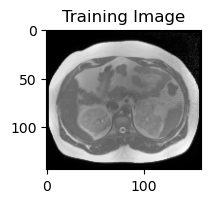

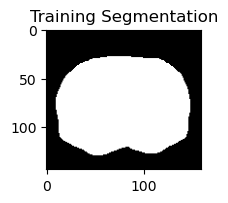

In [2]:
M = 6
noOfSamples = 200
vm = 0.005
numIter = 5000

# Load data
clip0 = np.load('dataForNN_inside_clip0.npy', allow_pickle=True).tolist()

TI = clip0['trainingImage']
TS = clip0['trainingSegmentation']
TestI = clip0['testImage']
TestS = clip0['testSegmentation']

# Show image
plt.figure(figsize=(2,2))
plt.imshow(clip0['trainingImage'], cmap='gray')
plt.title('Training Image')
plt.show()

plt.figure(figsize=(2,2))
plt.imshow(clip0['trainingSegmentation'], cmap='gray')
plt.title('Training Segmentation')
plt.show()

In [50]:
def getInputFeatures(image, numberOfNeighbors, shift=1):
    """
    Provides images patches as input features based on numberOfNeighbors
    """
    numberOfFeatures = numberOfNeighbors + 1

    leftNeighborImage = np.zeros_like(image)
    leftNeighborImage[:, shift:] = image[:, :-shift]

    rightNeighborImage = np.zeros_like(image)
    rightNeighborImage[:, :-shift] = image[:, shift:]

    topNeighborImage = np.zeros_like(image)
    topNeighborImage[shift:, :] = image[:-shift, :]

    bottomNeighborImage = np.zeros_like(image)
    bottomNeighborImage[:-shift, :] = image[shift:, :]

    leftTopNeighborImage = np.zeros_like(image)
    leftTopNeighborImage[shift:, shift:] = image[:-shift, :-shift]

    rightTopNeighborImage = np.zeros_like(image)
    rightTopNeighborImage[shift:, :-shift] = image[:-shift, shift:]

    leftBottomNeighborImage = np.zeros_like(image)
    leftBottomNeighborImage[:-shift, shift:] = image[shift:, :-shift]

    rightBottomNeighborImage = np.zeros_like(image)
    rightBottomNeighborImage[:-shift, :-shift] = image[shift:, shift:]

    if numberOfNeighbors == 0:
        features = image.ravel()
    elif numberOfNeighbors == 1:
        features = np.column_stack((image.ravel(), bottomNeighborImage.ravel()))
    elif numberOfNeighbors == 4:
        features = np.column_stack((
            image.ravel(),
            leftNeighborImage.ravel(),
            rightNeighborImage.ravel(),
            topNeighborImage.ravel(),
            bottomNeighborImage.ravel()
        ))
    elif numberOfNeighbors == 8:
        features = np.column_stack((
            image.ravel(),
            leftTopNeighborImage.ravel(),
            topNeighborImage.ravel(),
            rightTopNeighborImage.ravel(),
            leftNeighborImage.ravel(),
            rightNeighborImage.ravel(),
            leftBottomNeighborImage.ravel(),
            bottomNeighborImage.ravel(),
            rightBottomNeighborImage.ravel()
        ))
    else:
        raise NotImplementedError("Number of neighbors not implemented yet")

    featureImage = features.reshape((image.shape[0], image.shape[1], numberOfFeatures))
    return featureImage

def getSamples(featureImage, segmentation, numberOfSamples, mask=None):
    """
    Collects sample data
    """
    if mask is None:
        mask = np.ones(segmentation.shape)

    numberOfFeatures = featureImage.shape[2]
    numberOfPixels = featureImage.shape[0] * featureImage.shape[1]

    numberOfSamplesPerClass = int(np.ceil(numberOfSamples / 2))
    x = np.zeros((numberOfSamplesPerClass, numberOfFeatures, 2))
    t = np.zeros((numberOfSamplesPerClass, 2))
    rowAndColNumbers = np.zeros((numberOfSamplesPerClass, 2, 2))

    oneHotEncoding = np.zeros((segmentation.shape[0], segmentation.shape[1], 2))
    oneHotEncoding[:, :, 0] = segmentation
    oneHotEncoding[:, :, 1] = 1 - segmentation

    rows, cols = np.meshgrid(np.arange(1, featureImage.shape[0] + 1),
                             np.arange(1, featureImage.shape[1] + 1))

    for k in range(2):
        indices = np.where(oneHotEncoding[:, :, k] * mask)
        n_samp = min(numberOfSamplesPerClass, len(indices[0]))
        if n_samp > 0:
            sampleIndices = np.random.choice(len(indices[0]), n_samp, replace=False)
        else:
            continue
        indices = (indices[0][sampleIndices], indices[1][sampleIndices])

        x[:, :, k] = featureImage[indices[0], indices[1]]
        t[:, k] = segmentation[indices[0], indices[1]]
        rowAndColNumbers[:, :, k] = np.stack((indices[0], indices[1]), axis=1)

    x = np.concatenate((x[:, :, 0], x[:, :, 1]), axis=0)
    t = np.concatenate((t[:, 0], t[:, 1]), axis=0)
    rowAndColNumbers = np.concatenate((rowAndColNumbers[:, :, 0], rowAndColNumbers[:, :, 1]), axis=0)

    x = x[:numberOfSamples, :]
    t = t[:numberOfSamples]
    rowAndColNumbers = rowAndColNumbers[:numberOfSamples, :]

    return x, t, rowAndColNumbers

def showLocationOfSamples(image, rowAndColNumbers, t):
    """
    Plots the collected sample data
    """
    colors = ['b', 'r']
    markers = ['o', 'x']

    plt.imshow(image, cmap='gray')
    T = np.zeros([rowAndColNumbers.shape[0], 2])
    T[:,0] = t
    T[:,1] = t-1
    for k in range(2):
        tmp = rowAndColNumbers[np.where(T[:, k]), :]
        marker = markers[k]
        color = colors[k]
        plt.scatter(tmp[:,:,1], tmp[:,:,0], marker=marker, color=color, linewidth=0.75)
    
    plt.show

def plotSeg(image, segmentation):
    """
    Overlays a segmentation on top of an image
    """
    tmp = np.zeros((segmentation.shape[0], segmentation.shape[1], 3))
    tmp[:, :, 0] = 1 - segmentation
    tmp[:, :, 2] = segmentation
    plt.figure(figsize=(4,4))
    plt.imshow(image, cmap='gray')
    plt.imshow(tmp, alpha = 0.5)

## Task 1: Pixel-wise logistic regression classifier

For the data file ```dataForNN_inside_clip0.mat``` implement a pixel-wise logistic regression classifier $p(l \vert d, \theta)$, using fixed basis functions of the form

$$ \phi_m (d) = \cos[\pi(m-1)d] $$

You can use $\hat{w}_m = 0, \forall m$ for initializing the stochastic gradient descent algorithm.

Include in your report:
- a plot of the evolution of the cross-entropy across iterations
- the final segmentation of the test image
- the quantity $a$ and the obtained classifier (as in figure ...)
- visualization of where training samples are located (e.g. show $N^{\prime}$ samples of the last iteration of the stochastic gradient descent algorithm)

> ***Hints:***
> - getInputFeatures() provides images patches as input features based on ```numberOfNeighbors```
> - getSamples() collects sample data
> - showLocationOfSamples() plots the collected sample data
> - def plotSeg() overlays a segmentation on top of an image
>
> - for the sake of simplicity, you should compute the gradient $\nabla E_{N^{\prime}}(\theta)$ using the method of infinite differences. E.g. 
>       
>       gradient[n] = (newCost - cost[i]) / delta
>
>   computes the gradient for the $i^{th}$ iteration for the $n^{th}$ theta parameter 


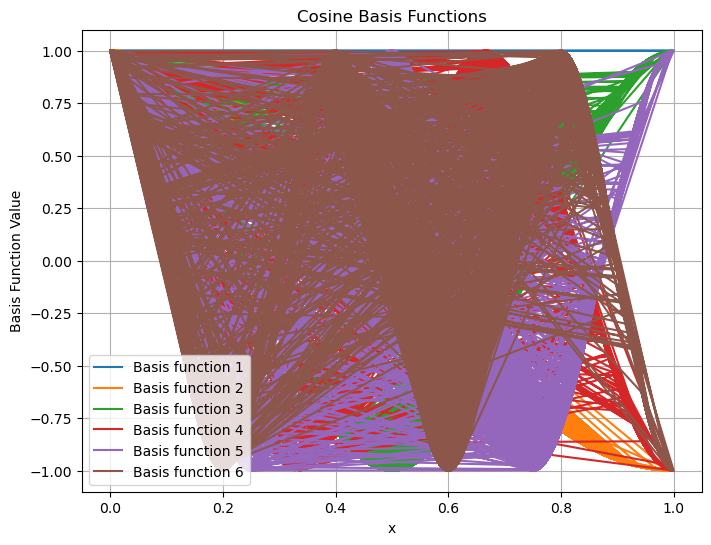

In [4]:
N = 200
M = 6
TI_flat = TI.flatten()
TS_flat = TS.flatten()

x = (TI_flat - TI_flat.min()) / (TI_flat.max() - TI_flat.min())   #d must be in [0,1] typically; adjust as needed
basis_functions = np.zeros((len(x), M))
for m in range(1, M+1):  # m=1,...,M
    basis_functions[:, m-1] = np.cos(np.pi * (m-1) * x)

#Plot basis functions
plt.figure(figsize=(8, 6))
for m in range(M):
    plt.plot(x, basis_functions[:, m], label=f'Basis function {m+1}')
plt.title('Cosine Basis Functions')
plt.xlabel('x')
plt.ylabel('Basis Function Value')
plt.legend()
plt.grid()
plt.show()

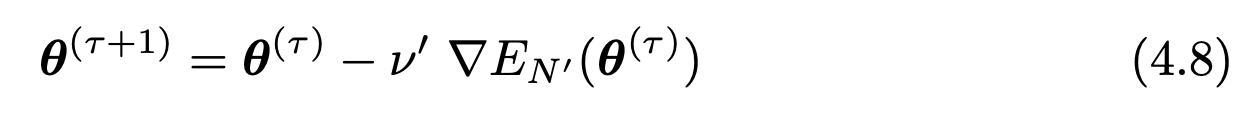

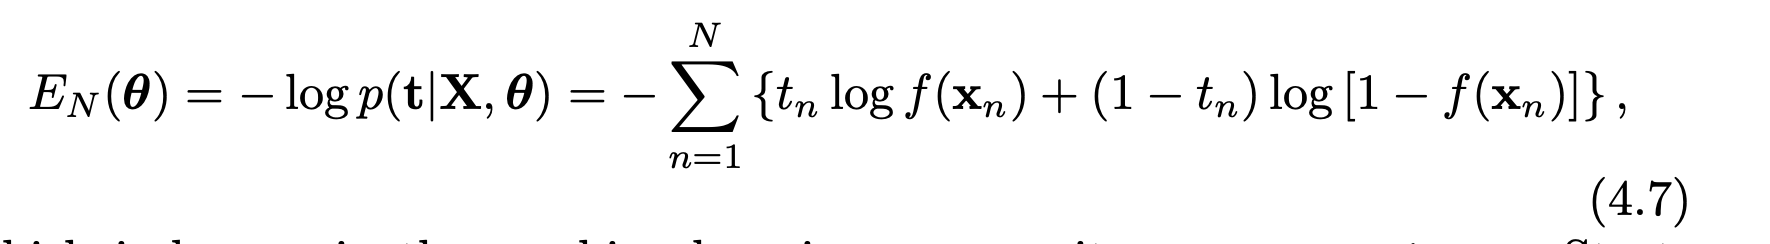

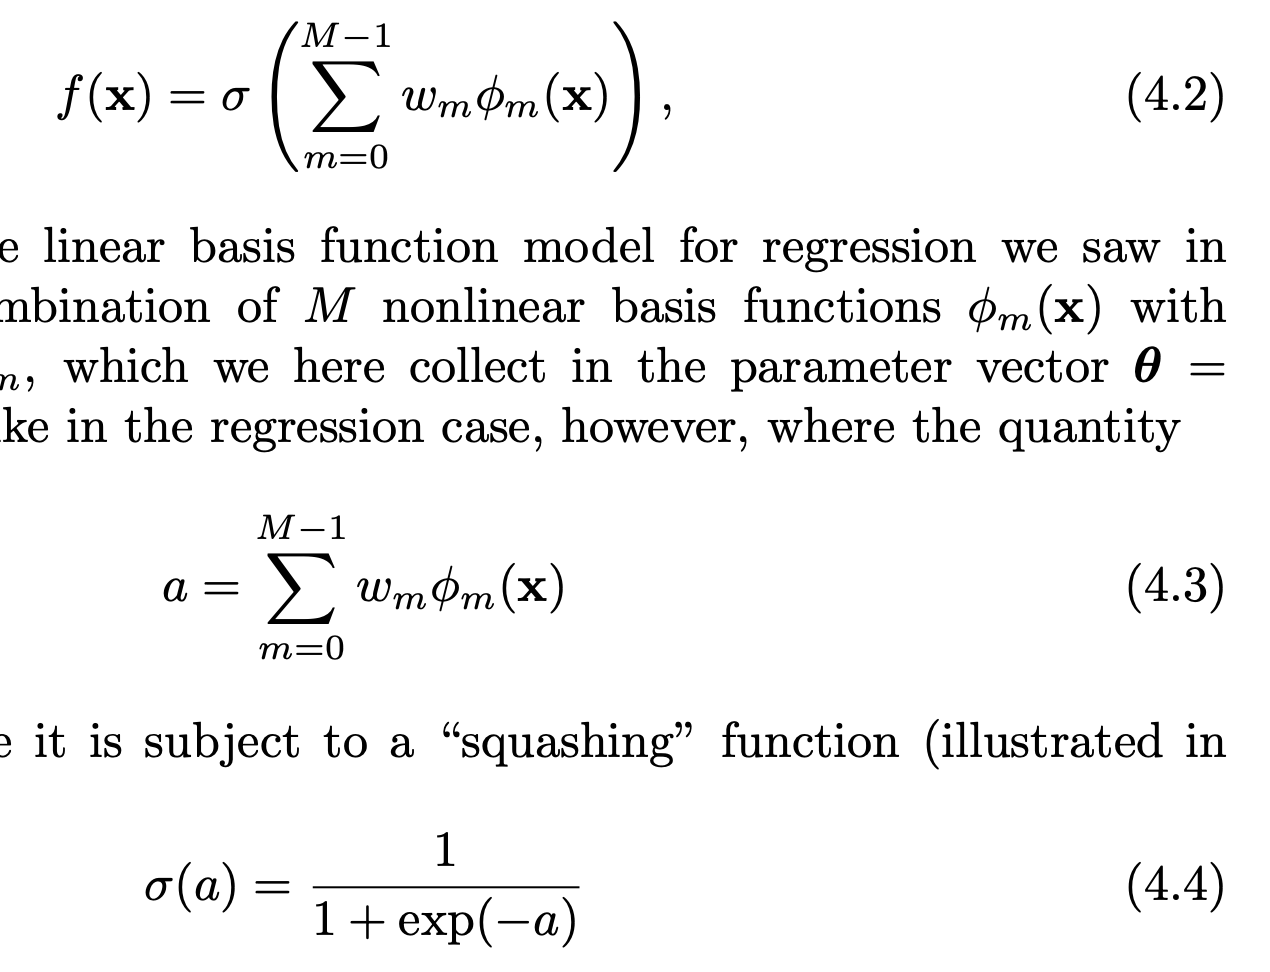

In [5]:
#creating sigma term
def create_sigma(basis_functions, theta):

    a = basis_functions @ theta    
    sigma = 1/(1 + np.exp(-a))
    return sigma

#Vi ved at f(x)=sigma(a)
#Laver eq. 4.7 som function (cross-entropy function)
def negative_log_likelihood(theta, basis_functions, t):
    f = create_sigma(basis_functions, theta)

    # avoid log(0)
    eps = 1e-12
    f = np.clip(f, eps, 1 - eps)

    return -np.sum(t * np.log(f) + (1 - t) * np.log(1 - f))

#Laver gradient af E(w) (Taget fra bogen)
def gradient(theta, basis_functions, t,delta=1e-5):
    grad = np.zeros_like(theta)
    for n in range(len(theta)):
        theta_eps = theta.copy()
        theta_eps[n] += delta
        grad[n] = (negative_log_likelihood(theta_eps, basis_functions, t) -
                   negative_log_likelihood(theta, basis_functions, t)) / delta
    return grad

#skal lave eq. 4.8 som function
def updating_theta(theta, basis_functions, t, vm):
    grad = gradient(theta, basis_functions, t)
    return theta - vm * grad

#sætter det hele sammen i et træningsloop
def train_model_SGD(basis_functions, t, M, vm, numIter):
    theta = np.zeros(M)  # initialize as zeros
    loss_history = []

    N = len(t)
    for i in range(numIter):
        # pick a random pixel
        idx = np.random.randint(0, N)
        x_i = basis_functions[idx:idx+1, :]  # shape (1,M)
        t_i = t[idx:idx+1]                    # shape (1,)
        
        grad = gradient(theta, x_i, t_i)
        theta = theta - vm * grad
        
        # record full batch NLL for plotting
        loss = negative_log_likelihood(theta, basis_functions, t)
        loss_history.append(loss)

    plt.figure(figsize=(8,6))
    plt.plot(range(numIter), loss_history, '-b')
    plt.title('Negative Log-Likelihood over Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Negative Log-Likelihood')
    plt.grid()
    plt.show()  

    return theta





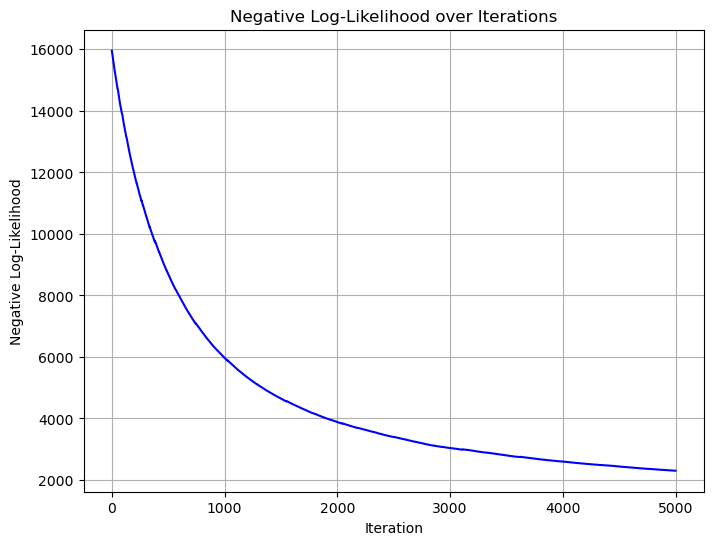

Learned theta: [-0.0717548   0.15022365 -2.72180731 -0.96226174  0.77555798 -0.66825299]


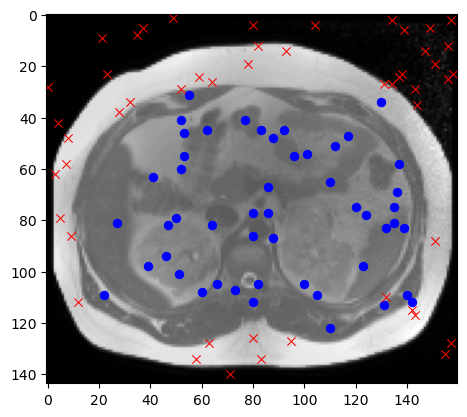

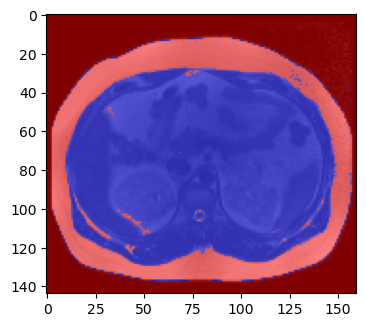

In [6]:
theta_final = train_model_SGD(basis_functions, TS_flat, M, vm, numIter)

print("Learned theta:", theta_final)

a = basis_functions @ theta_final
sigma = 1 / (1 + np.exp(-a))
segmentation = (sigma > 0.5).reshape(TI.shape)

numberOfNeighbors = 0  # or 4 / 8 depending on your preference
featureImage = getInputFeatures(TI, numberOfNeighbors)

# Now pass featureImage to getSamples
x_samples, t_samples, rowAndColNumbers = getSamples(featureImage, segmentation, numberOfSamples=100)

# Show the locations
showLocationOfSamples(TI, rowAndColNumbers, t_samples)
# plot segmentation on top of original image
plotSeg(TI, segmentation)



The following functions are provided:

    getInputFeatures(), getSamples(), showLocationOfSamples(), plotSeg()

## Task 2: Manipulate Intensities in Test Image

Create a new test image by replacing the intensities in the original test image using the rule
$$ d_{new} = d^{1.3}. $$

Use the classifier trained above to segment this new test image.

In your report, reflect on the result you obtain. Do the two test images look similar? What about their segmentations?

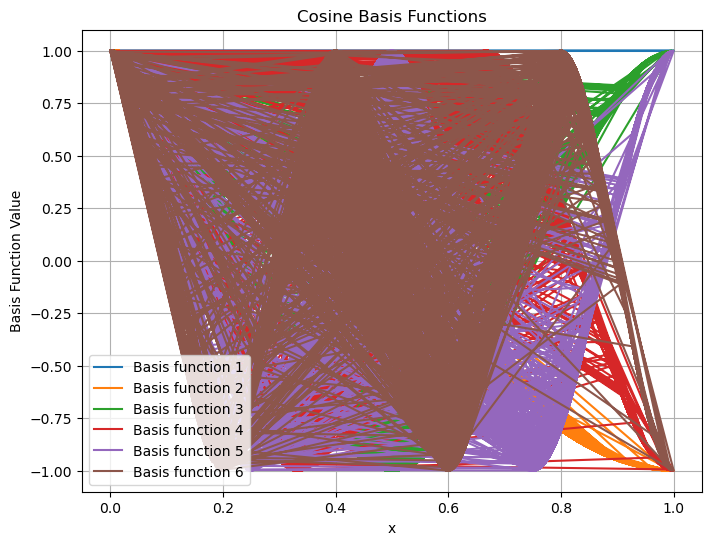

In [7]:
#Creating the new basis functions for the test image
N = 200
M = 6
TI_new = TI**1.3
TI_flat = TI_new.flatten()
TS_flat = TS.flatten()

x = (TI_flat - TI_flat.min()) / (TI_flat.max() - TI_flat.min())   #d must be in [0,1] typically; adjust as needed
basis_functions_new = np.zeros((len(x), M))
for m in range(1, M+1):  # m=1,...,M
    basis_functions_new[:, m-1] = np.cos(np.pi * (m-1) * x)

#Plot basis functions
plt.figure(figsize=(8, 6))
for m in range(M):
    plt.plot(x, basis_functions_new[:, m], label=f'Basis function {m+1}')
plt.title('Cosine Basis Functions')
plt.xlabel('x')
plt.ylabel('Basis Function Value')
plt.legend()
plt.grid()
plt.show()

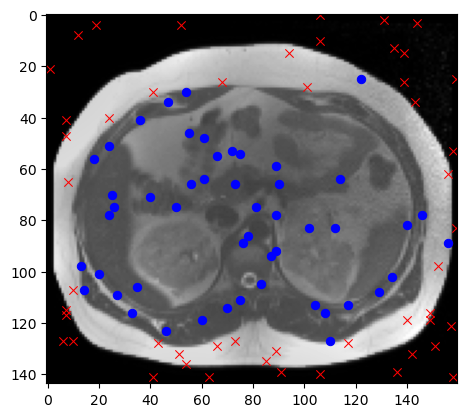

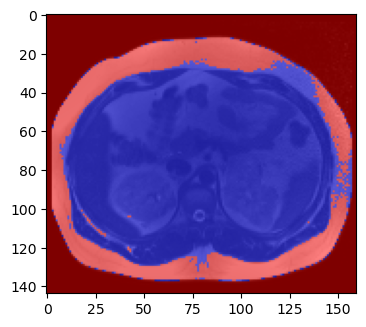

In [8]:

a = basis_functions_new @ theta_final
sigma = 1 / (1 + np.exp(-a))
segmentation = (sigma > 0.5).reshape(TI_new.shape)

numberOfNeighbors = 0  # or 4 / 8 depending on your preference
featureImage = getInputFeatures(TI_new, numberOfNeighbors)

# Now pass featureImage to getSamples
x_samples, t_samples, rowAndColNumbers = getSamples(featureImage, segmentation, numberOfSamples=100)

# Show the locations
showLocationOfSamples(TI_new, rowAndColNumbers, t_samples)
# plot segmentation on top of original image
plotSeg(TI_new, segmentation)



2️⃣ When you modify the intensities (d_new = d^1.3)
The intensity distribution is nonlinearly transformed.
Dark pixels get slightly darker (d^1.3 < d for d < 1).
Bright pixels get brighter (d^1.3 > d for d > 1).
The relative positions of pixel values change. Some pixels that were “bright enough” to be classified as class 1 may now appear darker, and vice versa.


3️⃣ Consequence for segmentation
Since the classifier sees these shifted intensity values, it may misclassify pixels:
Some regions that were correctly classified may now flip.
Boundaries may shift or become fuzzy.
Overall, the segmentation quality typically degrades, even though the objects in the image are the same.

## Task 3: Adaptive Basis Functions

Now replace the fixed cosine basis functions in your model with adaptive ones of the type Eq. (4.9), and train the classifier again. The extra parameters $\beta_{m,j}$ can be initialized randomly, distributed according to a zero-mean Gaussian distribution with unit variance. For the trained model, visualize again the obtained classifier and the resulting segmentation of the original test image. This time, also include a plot of the estimated basis functions $\phi_m(d)$.



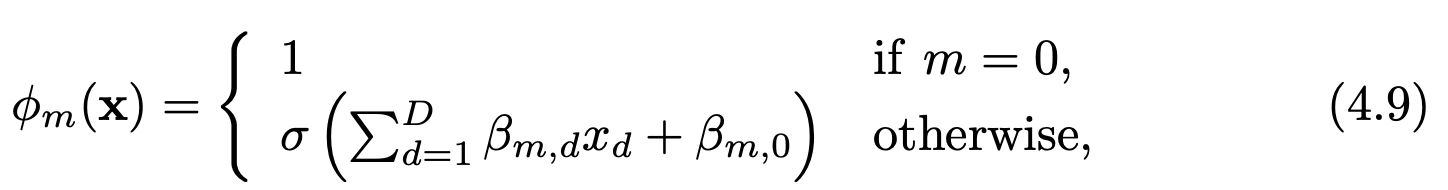

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#Based on eq. 4.9
def compute_basis_functions(X, B, b0):
    """
    X: (N, D) input features
    B: (M, D) weight matrix for basis functions
    b0: (M,) bias for each basis function
    Returns:
        Phi: (N, M) basis function values
    """
    N, D = X.shape
    M = B.shape[0]
    Phi = np.zeros((N, M))
    
    # phi_0 = 1
    Phi[:, 0] = 1
    
    # other basis functions
    for m in range(1, M):
        z = X @ B[m, :].T + b0[m]  # linear combination
        Phi[:, m] = sigmoid(z)
    
    return Phi

#New training function where we also update B and b0
def train_adaptive_basis(X, t, M=6, numIter=5000, lr=0.01):
    """
    X: N x D feature matrix
    t: N labels
    M: number of basis functions
    """
    N, D = X.shape
    # Initialize
    B = np.random.randn(M, D)    # adaptive basis weights
    b0 = np.random.randn(M)      # biases
    theta = np.zeros(M)          # logistic regression weights

    loss_history = []

    for it in range(numIter):
        # Compute basis functions for current B,b0
        Phi = compute_basis_functions(X, B, b0)
        f = sigmoid(Phi @ theta)

        # Sample a single pixel for SGD
        idx = np.random.randint(0, N)
        phi_i = Phi[idx:idx+1, :]
        x_i = X[idx:idx+1, :]
        t_i = t[idx]

        # Gradient w.r.t theta
        grad_theta = phi_i.T * (f[idx] - t_i)

        # Gradients w.r.t B and b0 (chain rule)
        grad_B = np.zeros_like(B)
        grad_b0 = np.zeros_like(b0)
        for m in range(1, M):
            s = f[idx] - t_i
            phi_m = Phi[idx, m]
            dphi = phi_m * (1 - phi_m)  # derivative of sigmoid
            grad_B[m, :] = s * theta[m] * dphi * x_i
            grad_b0[m] = s * theta[m] * dphi

        # SGD update
        theta -= lr * grad_theta.flatten()
        B -= lr * grad_B
        b0 -= lr * grad_b0

        
        loss = negative_log_likelihood(theta, compute_basis_functions(X, B, b0), t)
        loss_history.append(loss)

    # Plot NLL
    plt.figure(figsize=(8,6))
    plt.plot(np.arange(0,len(loss_history))*100, loss_history, '-b')
    plt.title('Negative Log-Likelihood (Adaptive Basis)')
    plt.xlabel('Iteration')
    plt.ylabel('NLL')
    plt.grid()
    plt.show()

    return theta, B, b0

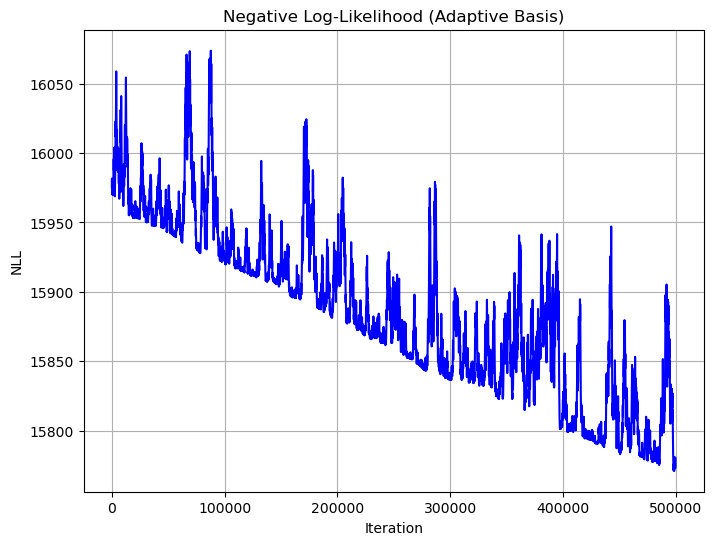

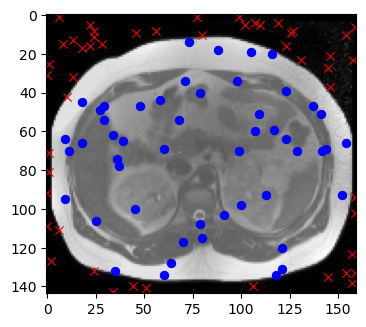

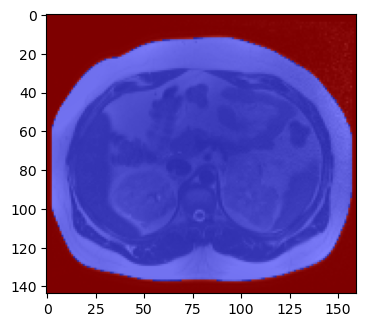

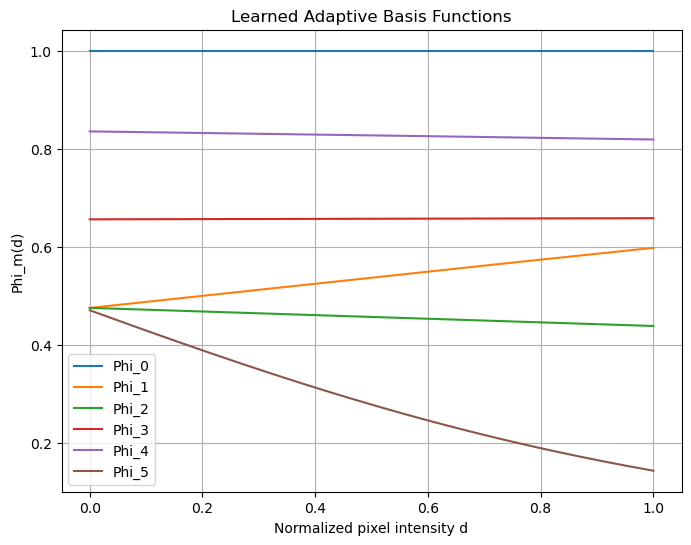

In [39]:
numberOfNeighbors = 0
featureImage = getInputFeatures(TI, numberOfNeighbors)
N, D = featureImage.shape[0]*featureImage.shape[1], featureImage.shape[2]
X = featureImage.reshape((N, D))
t = TS.flatten()

# Train fully adaptive model
M = 6
vm = 0.01
numIter = 5000
theta_final, B_final, b0_final = train_adaptive_basis(X, t, M, numIter=numIter, lr=vm)

# Compute segmentation
Phi_final = compute_basis_functions(X, B_final, b0_final)
sigma_out = sigmoid(Phi_final @ theta_final)
segmentation = (sigma_out > 0.5).reshape(TI.shape)
plotSeg(TI, segmentation)

# Safe sample visualization
x_samples, t_samples, rowAndColNumbers = getSamples(featureImage, segmentation, numberOfSamples=100)
showLocationOfSamples(TI, rowAndColNumbers, t_samples)
plotSeg(TI, segmentation)

# Plot estimated basis functions φ_m(d)
d_values = np.linspace(0,1,200).reshape(-1,1)
D = featureImage.shape[2]
d_values_full = np.zeros((len(d_values), D))
d_values_full[:,0] = d_values[:,0]
Phi_plot = compute_basis_functions(d_values_full, B_final, b0_final)

plt.figure(figsize=(8,6))
for m in range(M):
    plt.plot(d_values, Phi_plot[:, m], label=f'Phi_{m}')
plt.title('Learned Adaptive Basis Functions')
plt.xlabel('Normalized pixel intensity d')
plt.ylabel('Phi_m(d)')
plt.legend()
plt.grid()
plt.show()

Each time you run the code, the starting point of your adaptive basis functions is different.
Since the model is non-linear (sigmoid + adaptive basis + logistic regression), the training can converge to a different local minimum depending on the initialization.
This is why the segmentation looks different each time.

## Task 4: Use Neighbour Pixel as second Input Feature

Using the data in the file ```dataForNN_foreBorder_clip1.mat```, re-train and re-apply your classifier, but this time not just based on the intensity in the pixel being classified, but also on that of the pixel in the next row (i.e., the input x is now a vector of dimension $p = 2$). In addition to showing the classifier output on the test image, also include in your report a visualization of the learned basis functions $\phi_m(d)$ in the 2D input space, along with the learned classifier (again in the 2D input space). For the latter, please include a visualization of where the training samples $\{x_i , y_i \}$ are located (cf. the first task).

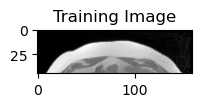

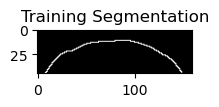

In [47]:
#Loading the data
M = 6
noOfSamples = 200
vm = 0.005
numIter = 5000

# Load data
clip0 = np.load('dataForNN_foreBorder_clip1.npy', allow_pickle=True).tolist()

TI_b = clip0['trainingImage']
TS_b = clip0['trainingSegmentation']
TestI_b = clip0['testImage']
TestS_b = clip0['testSegmentation']

# Show image
plt.figure(figsize=(2,2))
plt.imshow(clip0['trainingImage'], cmap='gray')
plt.title('Training Image')
plt.show()

plt.figure(figsize=(2,2))
plt.imshow(clip0['trainingSegmentation'], cmap='gray')
plt.title('Training Segmentation')
plt.show()

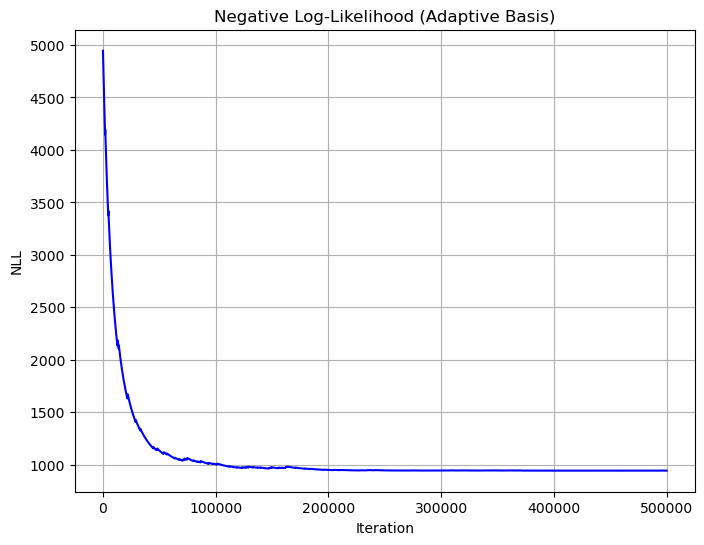

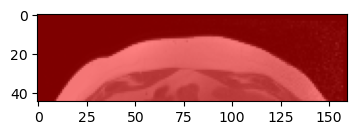

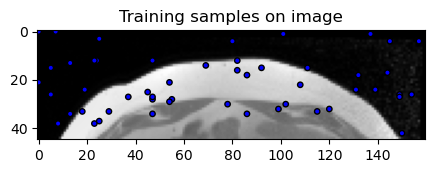

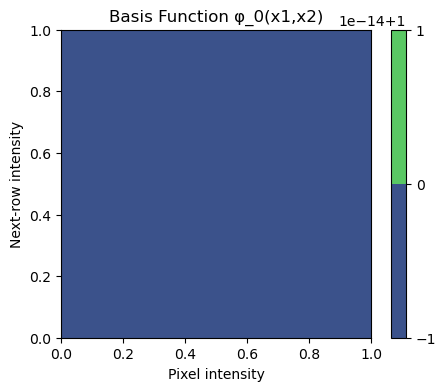

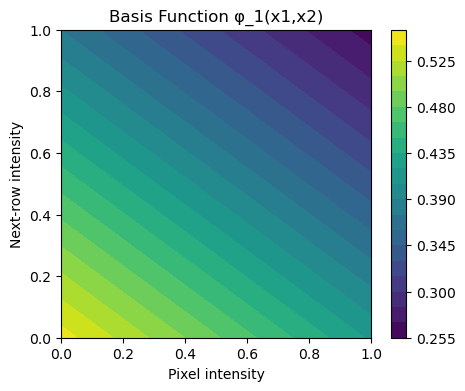

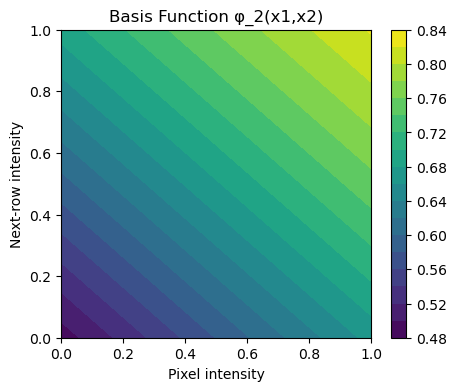

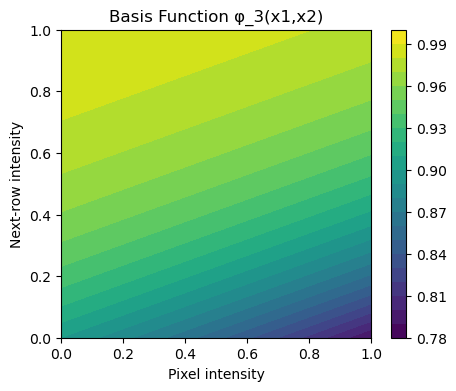

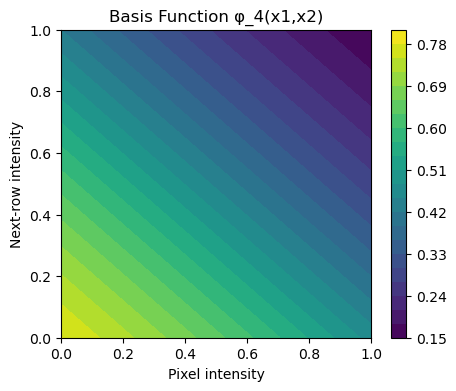

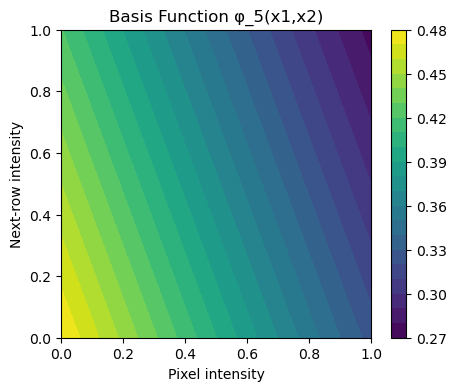

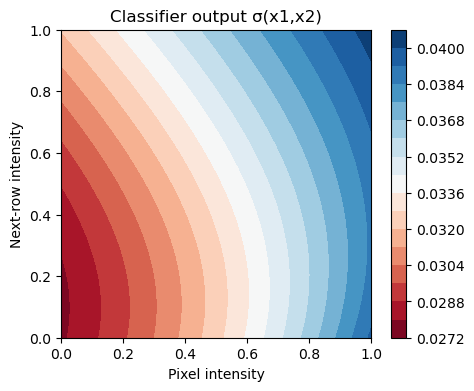

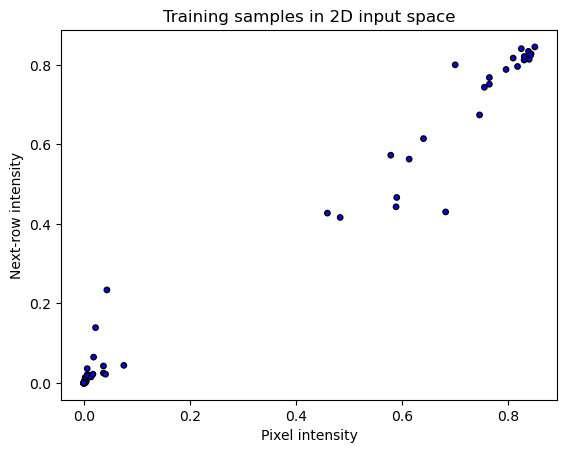

In [52]:
# Only two features: pixel + next row
numberOfNeighbors = 1
featureImage = getInputFeatures(TI_b, numberOfNeighbors)
N, D = featureImage.shape[0]*featureImage.shape[1], featureImage.shape[2]
X = featureImage.reshape((N,D))
t = TS_b.flatten()

# Train adaptive model
M = 6
theta_final, B_final, b0_final = train_adaptive_basis(X, t, M, numIter=5000, lr=0.01)

# Compute segmentation
Phi_final = compute_basis_functions(X, B_final, b0_final)
sigma_out = sigmoid(Phi_final @ theta_final)
segmentation = (sigma_out > 0.5).reshape(TI_b.shape)
plotSeg(TI_b, segmentation)

# Training sample visualization
x_samples, t_samples, coords = getSamples(featureImage, segmentation, numberOfSamples=100)
plt.figure(figsize=(5,5))
plt.imshow(TI_b, cmap='gray')
plt.scatter(coords[:,1], coords[:,0], c=t_samples, cmap='bwr', s=15, edgecolor='k')
plt.title('Training samples on image')
plt.show()

# Plot estimated basis functions φ_m(x1,x2)
x1 = np.linspace(0,1,50)
x2 = np.linspace(0,1,50)
X1, X2 = np.meshgrid(x1, x2)
X_full = np.zeros((X1.size, 2))
X_full[:,0] = X1.flatten()
X_full[:,1] = X2.flatten()
Phi_grid = compute_basis_functions(X_full, B_final, b0_final)

for m in range(M):
    plt.figure(figsize=(5,4))
    plt.contourf(X1, X2, Phi_grid[:,m].reshape(X1.shape), levels=20, cmap='viridis')
    plt.colorbar()
    plt.title(f'Basis Function φ_{m}(x1,x2)')
    plt.xlabel('Pixel intensity')
    plt.ylabel('Next-row intensity')
    plt.show()


sigma_grid = sigmoid(Phi_grid @ theta_final)
plt.figure(figsize=(5,4))
plt.contourf(X1, X2, sigma_grid.reshape(X1.shape), levels=20, cmap='RdBu')
plt.colorbar()
plt.title('Classifier output σ(x1,x2)')
plt.xlabel('Pixel intensity')
plt.ylabel('Next-row intensity')
plt.show()

# Overlay training samples
plt.scatter(x_samples[:,0], x_samples[:,1], c=t_samples, cmap='bwr', s=15, edgecolor='k')
plt.xlabel('Pixel intensity')
plt.ylabel('Next-row intensity')
plt.title('Training samples in 2D input space')
plt.show()

## Task 5: Use 8 Neighbours as Input Features

Using the data in the file ```dataForNN_foreBorder_clip0.mat```, re-train and re-apply the same classifier, but now using 3 × 3 patches as input, i.e., the input $x$ is now a vector of dimension $p = 9$. In your report you should include the classifier output on the test image, as well as the feature maps and the corresponding model weights $\{ \beta_{m,j} \}^{p}_{j=1}$ as visualized in Fig. 4.5(d) and Fig. 4.5(e), respectively.

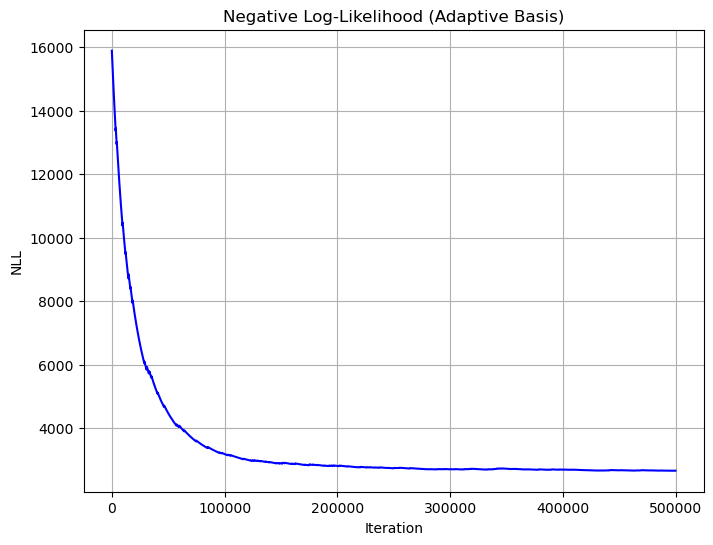

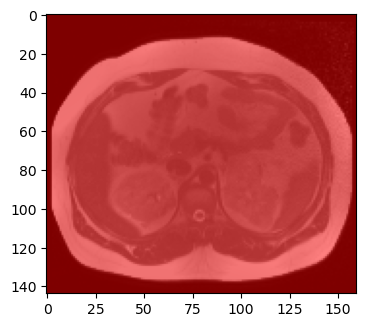

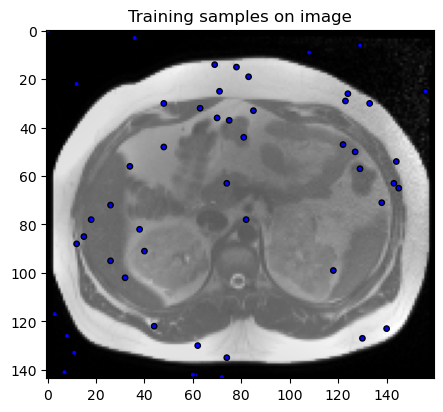

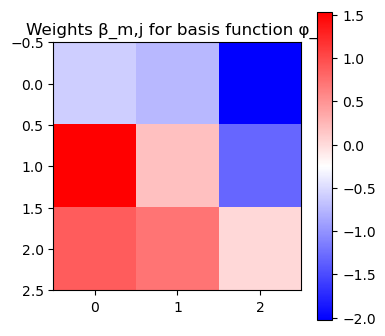

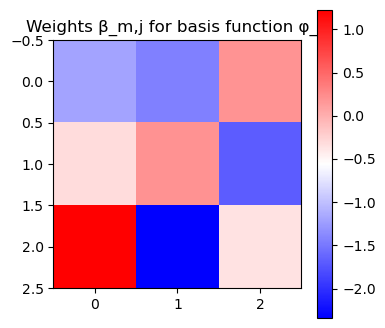

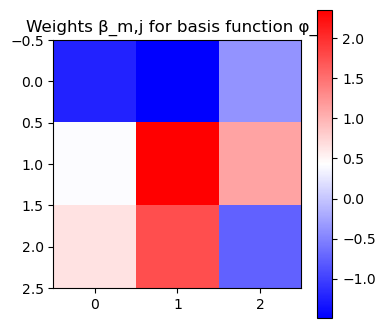

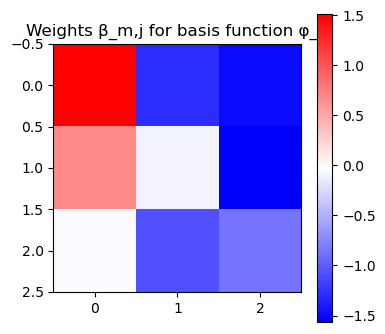

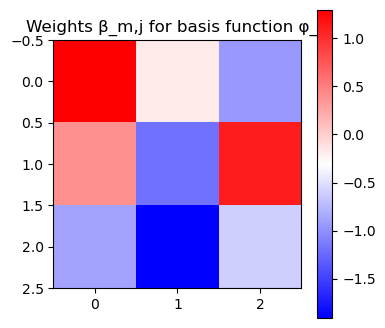

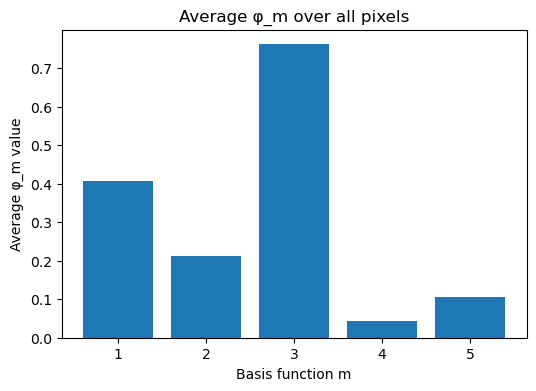

In [54]:
clip0 = np.load('dataForNN_foreBorder_clip0.npy', allow_pickle=True).tolist()
TI_0 = clip0['trainingImage']
TS_0 = clip0['trainingSegmentation']
TestI_0 = clip0['testImage']
TestS_0 = clip0['testSegmentation']

# 3x3 patch features → 8 neighbors + central pixel
numberOfNeighbors = 8
featureImage = getInputFeatures(TI_0, numberOfNeighbors)
N, D = featureImage.shape[0]*featureImage.shape[1], featureImage.shape[2]
X = featureImage.reshape((N,D))
t = TS_0.flatten()

# Train adaptive basis
M = 6
theta_final, B_final, b0_final = train_adaptive_basis(X, t, M, numIter=5000, lr=0.01)

# Compute segmentation
Phi_final = compute_basis_functions(X, B_final, b0_final)
sigma_out = sigmoid(Phi_final @ theta_final)
segmentation = (sigma_out > 0.5).reshape(TI.shape)
plotSeg(TI_0, segmentation)

# Visualize training samples
x_samples, t_samples, coords = getSamples(featureImage, segmentation, numberOfSamples=100)
plt.figure(figsize=(5,5))
plt.imshow(TI_0, cmap='gray')
plt.scatter(coords[:,1], coords[:,0], c=t_samples, cmap='bwr', s=15, edgecolor='k')
plt.title('Training samples on image')
plt.show()

# -----------------------------
# 7️⃣ Visualize model weights B (β_{m,j}) as a heatmap per basis function
# -----------------------------
for m in range(1,M):
    plt.figure(figsize=(4,4))
    plt.imshow(B_final[m,:].reshape((3,3)), cmap='bwr', interpolation='nearest')
    plt.colorbar()
    plt.title(f'Weights β_m,j for basis function φ_{m}')
    plt.show()

# -----------------------------
# 8️⃣ Optional: visualize basis functions φ_m for central pixel vs neighbors
# -----------------------------
# For simplicity, you can plot φ_m averaged over all neighbors:
Phi_avg = Phi_final[:,1:].mean(axis=0)
plt.figure(figsize=(6,4))
plt.bar(range(1,M), Phi_avg)
plt.title('Average φ_m over all pixels')
plt.xlabel('Basis function m')
plt.ylabel('Average φ_m value')
plt.show()

## Task 6: (for the enthusiastic student)

In order to provide a more challenging task to the neural network, do task 4 again but this time using the data in the file ```dataForNN_foreBorder_clip0.mat```. Concentrate on the visualization of the learned basis functions and especially that of the classifier with respect to the training samples. Can you explain why this scenario is more challenging than the one of task 4? You can also try to add another hidden layer in the network – what do the basis functions look like now?